# Build Incidence CSV for Calibration (Santa Marta)

This notebook extracts weekly dengue incidence for Santa Marta (2023–2024), adjusts for 87% underreporting, and exports a calibration-ready CSV with columns `week`, `week_continuous`, and `incidence_rate_adjusted`.

Window: from epidemiological week 26 of 2023 for exactly one year (52 weeks). A comparison plot of reported vs adjusted ("real") is included for that window.


In [1]:
# Imports and file paths
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('../santa_marta_data')
FILE_210_2023 = DATA_DIR / 'Datos_2023_210.xlsx'
FILE_220_2023 = DATA_DIR / 'Datos_2023_220.xlsx'
FILE_210_2024 = DATA_DIR / 'Datos_2024_210.xlsx'
FILE_220_2024 = DATA_DIR / 'Datos_2024_220.xlsx'

POP_2023 = 555030  # Santa Marta population
UNDERREPORTING = 0.87  # 87%
ADJ_FACTOR = 1.0 / (1.0 - UNDERREPORTING)  # ~7.6923

OUT_CSV = Path('incidence_rates_santa_marta.csv')


In [ ]:
# Load Excel, find municipality and week columns, filter Santa Marta

def load_year(files_210_220, year: int) -> pd.DataFrame:
    f210, f220 = files_210_220
    d210 = pd.read_excel(f210)
    d220 = pd.read_excel(f220)
    # find municipality col
    muni_col = None
    for col in d210.columns:
        if 'municipio' in col.lower() and 'ocurr' in col.lower():
            muni_col = col
            break
    if muni_col is None:
        raise RuntimeError('Municipality column not found in 210 file')
    def filter_sm(df):
        return df[
            df[muni_col].astype(str).str.upper().str.contains('SANTA MART', na=False)
        ].copy()
    d210_sm = filter_sm(d210)
    d220_sm = filter_sm(d220)
    df = pd.concat([d210_sm, d220_sm], ignore_index=True)
    # find week col
    week_col = None
    for col in df.columns:
        if 'semana' in col.lower():
            week_col = col
            break
    if week_col is None:
        raise RuntimeError('Week column not found')
    weekly = df.groupby(week_col).size().reset_index(name='cases')
    weekly = weekly.rename(columns={week_col: 'week'})
    weekly['year'] = year
    return weekly

weekly_2023 = load_year((FILE_210_2023, FILE_220_2023), 2023)
weekly_2024 = load_year((FILE_210_2024, FILE_220_2024), 2024)

combined = pd.concat([
    weekly_2023.assign(week_continuous=weekly_2023['week']),
    weekly_2024.assign(week_continuous=weekly_2024['week'] + 52)
], ignore_index=True)
combined = combined.sort_values(['year','week']).reset_index(drop=True)
combined.head()


In [ ]:
# Compute adjusted cases and incidence per 100k
combined['adjusted_cases'] = combined['cases'] * ADJ_FACTOR
combined['incidence_rate_adjusted'] = (combined['adjusted_cases'] / POP_2023) * 100000
combined['incidence_rate_reported'] = (combined['cases'] / POP_2023) * 100000
combined.tail()


,week,cases,year,week_continuous,adjusted_cases,incidence_rate_adjusted,incidence_rate_reported
99,48,10,2024,100,76.923077,13.859265,1.801704
100,49,10,2024,101,76.923077,13.859265,1.801704
101,50,14,2024,102,107.692308,19.402971,2.522386
102,51,10,2024,103,76.923077,13.859265,1.801704
103,52,15,2024,104,115.384615,20.788897,2.702557


In [ ]:
# Build aligned window: week 26 of 2023 to 52 weeks later
start_week = 26
start_mask = (combined['year'] == 2023) & (combined['week'] >= start_week)
# Slice 2023 from week 26 onward, then 2024 until we reach 52 total weeks
w2023 = combined[start_mask].copy()
needed_2024 = max(0, 52 - len(w2023))
w2024 = combined[(combined['year'] == 2024)].copy()
window = pd.concat([w2023, w2024.head(needed_2024)], ignore_index=True)

# Ensure exactly 52 rows; if shorter, pad by forward-filling last known value
if len(window) < 52:
    pad_rows = 52 - len(window)
    last = window.tail(1).copy()
    pads = []
    for i in range(pad_rows):
        row = last.copy()
        row['week'] = int(row['week']) + (i + 1)
        row['week_continuous'] = int(window['week_continuous'].max()) + (i + 1)
        pads.append(row)
    if pads:
        window = pd.concat([window] + pads, ignore_index=True)

# Create aligned week indices 1..52
window = window.reset_index(drop=True)
window['aligned_week'] = np.arange(1, 53)
window.head(), len(window)


(   week  cases  year  week_continuous  adjusted_cases  \
 0    26      5  2023               26       38.461538   
 1    27     19  2023               27      146.153846   
 2    28     25  2023               28      192.307692   
 3    29     21  2023               29      161.538462   
 4    30     25  2023               30      192.307692   
 
    incidence_rate_adjusted  incidence_rate_reported  aligned_week  
 0                 6.929632                 0.900852             1  
 1                26.332603                 3.423238             2  
 2                34.648162                 4.504261             3  
 3                29.104456                 3.783579             4  
 4                34.648162                 4.504261             5  ,
 52)

In [ ]:
# Export calibration CSV (week, week_continuous, incidence_rate_adjusted)
calib = window[['aligned_week','week_continuous','incidence_rate_adjusted']].copy()
calib = calib.rename(columns={'aligned_week':'week'})
calib.to_csv(OUT_CSV, index=False)
print(f"\u2713 Wrote {OUT_CSV} with {len(calib)} rows")
calib.head()


✓ Wrote incidence_rates_santa_marta.csv with 52 rows


,week,week_continuous,incidence_rate_adjusted
0,1,26,6.929632
1,2,27,26.332603
2,3,28,34.648162
3,4,29,29.104456
4,5,30,34.648162


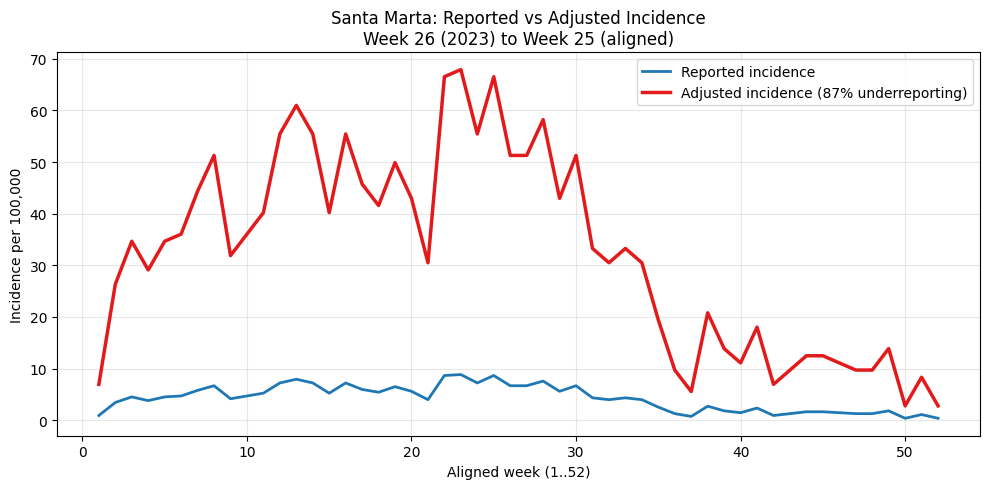

In [6]:
# Plot reported vs adjusted incidence for the 52-week window
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(window['aligned_week'], window['incidence_rate_reported'], color='#1f78b4', lw=2, label='Reported incidence')
ax.plot(window['aligned_week'], window['incidence_rate_adjusted'], color='#e31a1c', lw=2.5, label='Adjusted incidence (87% underreporting)')
ax.set_title('Santa Marta: Reported vs Adjusted Incidence\nWeek 26 (2023) to Week 25 (aligned)')
ax.set_xlabel('Aligned week (1..52)')
ax.set_ylabel('Incidence per 100,000')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
